# 04.2 — Baseline Comparison

Compares the engineered-feature pipeline selected in `04.1_model_training.ipynb` against reference baselines — majority-class, stratified-random, and TF-IDF text-only — and against several ways of combining TF-IDF with the engineered features.

This notebook is self-contained: it reloads the data and rebuilds the features and train/test split independently (same seed as `04.1_model_training.ipynb`, so results compare directly), rather than depending on `04.1_model_training.ipynb` having been run first.

## Setup

Reproduces the data load, `thread_id` grouping, feature matrix, and thread-grouped train/test split from `04.1_model_training.ipynb` (sections 8.1-8.3) — see that notebook for the reasoning behind each step.

In [1]:
import pandas as pd
import zipfile
import json

with zipfile.ZipFile('../results/03_cmv_comments_df.csv.zip') as z:
    comments_df = pd.read_csv(z.open(z.namelist()[0]))
comments_df = comments_df.copy()  # consolidate blocks - avoids a pandas PerformanceWarning on later single-column inserts

with open('../results/03_untrusted_features.json') as f:
    untrusted_features = json.load(f)

print(f'Loaded {len(comments_df)} rows, {comments_df.shape[1]} columns')
print(f'Untrusted features (used below only for the selected-pipeline reference point): {untrusted_features}')

Loaded 3971 rows, 237 columns
Untrusted features (used below only for the selected-pipeline reference point): ['sentiment_vader', 'tone_label', 'style_label', 'ethos_score', 'pathos_score', 'logos_score']


In [2]:
import hashlib

comments_df['thread_id'] = comments_df['original_post'].apply(
    lambda x: hashlib.md5(str(x).encode()).hexdigest()
)

print(f'Unique threads : {comments_df["thread_id"].nunique()}')
print(f'Total comments : {len(comments_df)}')

Unique threads : 401
Total comments : 3971


In [3]:
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import OneHotEncoder

# Comment-side, OP-side, and comment↔OP diff features from 03.1-03.3.
numeric_features = [
    'sentiment_llm', 'adj_adv_ratio', 'fk_grade_level', 'fk_reading_ease', 'evidence_count',
    'ethos_llm', 'pathos_llm', 'logos_llm',
    'sentiment_llm_op', 'adj_adv_ratio_op', 'fk_grade_level_op', 'evidence_count_op',
    'ethos_llm_op', 'pathos_llm_op', 'logos_llm_op',
    'sentiment_diff', 'ethos_diff', 'pathos_diff', 'logos_diff',
    'adj_adv_ratio_diff', 'fk_grade_level_diff', 'evidence_count_diff',
]
embedding_features = [c for c in comments_df.columns if c.startswith('embedding_')]
label = 'is_convincing'

categorical_features = ['tone_google', 'tone_google_op']
onehot_encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
tone_encoded = onehot_encoder.fit_transform(comments_df[categorical_features].fillna('unknown'))
tone_df = pd.DataFrame(tone_encoded, columns=onehot_encoder.get_feature_names_out(), index=comments_df.index)

comments_df['is_formal']    = (comments_df['style_google']    == 'Formal').astype(int)
comments_df['is_formal_op'] = (comments_df['style_google_op'] == 'Formal').astype(int)

match_features = ['sentiment_match', 'tone_match', 'style_match', 'ethos_match', 'pathos_match', 'logos_match']
match_df = comments_df[match_features].astype(int)

X = pd.concat([tone_df,
               comments_df[['is_formal', 'is_formal_op', 'use_of_persuasive_lang'] + numeric_features],
               match_df,
               comments_df[embedding_features]],
              axis=1)
y = comments_df[label]
groups = comments_df['thread_id']

print(f'Features : {X.shape[1]}  ({len(embedding_features)} of them PCA embedding components)')
print(f'Samples  : {X.shape[0]}')

Features : 228  (187 of them PCA embedding components)
Samples  : 3971


In [4]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

train_threads = set(groups.iloc[train_idx])
test_threads  = set(groups.iloc[test_idx])
assert len(train_threads & test_threads) == 0, 'LEAKAGE: shared threads between train and test!'
print(f'Train: {len(train_idx)} comments from {len(train_threads)} threads')
print(f'Test : {len(test_idx)} comments from {len(test_threads)} threads')

Train: 3262 comments from 320 threads
Test : 709 comments from 81 threads


## Reference Point — the Selected Pipeline

`04.1_model_training.ipynb`'s validation grid (9 classifiers × 3 resampling strategies × 3 feature sets) selected **XGBoost + SMOTE oversampling on the `trusted+untrusted` feature set** by validation PR-AUC. Rather than re-running that full 27-combination grid here, this refits just that one pipeline on the same thread-grouped split, to get a live, directly comparable reference point for the baselines below.

In [5]:
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import average_precision_score, roc_auc_score, f1_score
import warnings
warnings.filterwarnings('ignore')

untrusted_encoded = []
for col in untrusted_features:
    if pd.api.types.is_numeric_dtype(comments_df[col]):
        untrusted_encoded.append(comments_df[[col]].fillna(0))
    else:
        ohe = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
        encoded = ohe.fit_transform(comments_df[[col]].fillna('unknown'))
        untrusted_encoded.append(pd.DataFrame(encoded, columns=ohe.get_feature_names_out(), index=comments_df.index))

X_with_untrusted = pd.concat([X] + untrusted_encoded, axis=1)
X_train_selected = X_with_untrusted.iloc[train_idx]
X_test_selected  = X_with_untrusted.iloc[test_idx]

selected_pipe = Pipeline([
    ('scaler', RobustScaler()),
    ('sampler', SMOTE(random_state=42)),
    ('clf', xgb.XGBClassifier(random_state=42, eval_metric='logloss')),
])
selected_pipe.fit(X_train_selected, y_train)
proba_selected = selected_pipe.predict_proba(X_test_selected)[:, 1]
pred_selected  = selected_pipe.predict(X_test_selected)

pr_auc_selected  = average_precision_score(y_test, proba_selected)
roc_auc_selected = roc_auc_score(y_test, proba_selected)
f1_selected       = f1_score(y_test, pred_selected, zero_division=0)

print('Selected pipeline (XGB + SMOTE oversampling, trusted+untrusted features):')
print(f'Test PR-AUC  : {pr_auc_selected:.4f}')
print(f'Test ROC-AUC : {roc_auc_selected:.4f}')
print(f'Test F1 @ 0.5: {f1_selected:.4f}  (untuned threshold - see 04.1_model_training.ipynb for the validation-tuned figure)')

Selected pipeline (XGB + SMOTE oversampling, trusted+untrusted features):
Test PR-AUC  : 0.3848
Test ROC-AUC : 0.6982
Test F1 @ 0.5: 0.2513  (untuned threshold - see 04.1_model_training.ipynb for the validation-tuned figure)


## 8.7 Baselines

The selected pipeline's test PR-AUC (above) is only meaningful next to some reference points. Three baselines are evaluated below, on the exact same thread-grouped train/test split as the real models:

- **Majority-class** — always predicts "not convincing" (the majority class). Not learned at all; makes concrete why accuracy is a misleading metric on this imbalanced dataset.
- **Stratified-random** — predicts randomly, matching the training set's class frequencies. This is the actual "no-skill" reference (equal to the positive rate) that PR-AUC is judged against.
- **TF-IDF + Logistic Regression** — a standard, minimal-effort NLP baseline: raw comment text only, none of the engineered features (no sentiment/tone/ethos-pathos-logos/embeddings/OP-relation features). Tests whether the `03.1`-`03.3` feature-engineering effort is actually earning its complexity.

All are compared on PR-AUC and ROC-AUC (threshold-free, and the same primary/secondary metrics used throughout this project). F1 is also reported, but at each baseline's default 0.5 threshold rather than a validation-tuned one — unlike the selected pipeline, whose `04.1_model_training.ipynb` F1 used a threshold tuned on a validation set — so F1 isn't perfectly apples-to-apples between the two; PR-AUC is the fair comparison.

In [6]:
from sklearn.dummy import DummyClassifier

def bold_max(col):
    return ['font-weight: bold' if v == col.max() else '' for v in col]

baseline_results = {
    'Selected pipeline (XGB + SMOTE, trusted+untrusted)': {
        'PR-AUC': pr_auc_selected, 'ROC-AUC': roc_auc_selected, 'F1': f1_selected,
    },
}

for strategy, label in [('most_frequent', 'Majority-class'), ('stratified', 'Stratified-random')]:
    dummy = DummyClassifier(strategy=strategy, random_state=42)
    dummy.fit(X_train_selected, y_train)
    proba = dummy.predict_proba(X_test_selected)[:, 1]
    pred  = dummy.predict(X_test_selected)

    baseline_results[label] = {
        'PR-AUC':  average_precision_score(y_test, proba),
        'ROC-AUC': roc_auc_score(y_test, proba),
        'F1':      f1_score(y_test, pred, zero_division=0),
    }

pd.DataFrame(baseline_results).T.round(4)

,PR-AUC,ROC-AUC,F1
"Selected pipeline (XGB + SMOTE, trusted+untrusted)",0.3848,0.6982,0.2513
Majority-class,0.2031,0.5000,0.0000
Stratified-random,0.2013,0.4941,0.1699


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

text_train = comments_df['cleaned_final_comment'].iloc[train_idx].fillna('')
text_test  = comments_df['cleaned_final_comment'].iloc[test_idx].fillna('')

tfidf = TfidfVectorizer(max_features=5000, min_df=2)
X_text_train = tfidf.fit_transform(text_train)
X_text_test  = tfidf.transform(text_test)

tfidf_logreg = LogisticRegression(random_state=42, max_iter=1000)
tfidf_logreg.fit(X_text_train, y_train)
proba = tfidf_logreg.predict_proba(X_text_test)[:, 1]
pred  = tfidf_logreg.predict(X_text_test)

baseline_results['TF-IDF + LogReg'] = {
    'PR-AUC':  average_precision_score(y_test, proba),
    'ROC-AUC': roc_auc_score(y_test, proba),
    'F1':      f1_score(y_test, pred, zero_division=0),
}

pd.DataFrame(baseline_results).T.round(4).style.apply(bold_max, axis=0)

,PR-AUC,ROC-AUC,F1
"Selected pipeline (XGB + SMOTE, trusted+untrusted)",0.384800,0.698200,0.251300
Majority-class,0.203100,0.500000,0.000000
Stratified-random,0.201300,0.494100,0.169900
TF-IDF + LogReg,0.511900,0.815000,0.123500


**Majority-class** (PR-AUC 0.2031, F1 0.0) and **Stratified-random** (PR-AUC 0.2013, F1 0.1699) both land close to the no-skill baseline (the 0.161 positive rate — see `04.1_model_training.ipynb`). Majority-class's F1 of exactly 0 makes the accuracy point from that notebook's section 8.5 concrete: it would score 83.9% accuracy while never once correctly identifying a convincing comment.

**TF-IDF + Logistic Regression is the strongest result in this table.** Its PR-AUC (0.5119) and ROC-AUC (0.8150) are both clearly *ahead* of the selected pipeline reproduced above (PR-AUC 0.3848, ROC-AUC 0.6982) — despite using none of the engineered features from `03.1`-`03.3`, just raw comment text. Its F1 (0.1235) is lower than the selected pipeline's validation-tuned F1 in `04.1_model_training.ipynb` (0.4046), but that's a threshold artifact (default 0.5 here vs. validation-tuned there), not a genuine reversal — on the threshold-free metrics this notebook treats as primary and secondary, TF-IDF+LogReg wins clearly. That gap — a minimal-effort text-only model beating the full `03.1`-`03.3` feature-engineering pipeline — motivates the rest of this notebook: the feature-family ablation below (§8.8), then a combination strategy that actually works (§8.10).

## 8.8 Feature-Family Ablation

`TF-IDF + LogReg` already beats the selected engineered pipeline outright (previous section). That doesn't rule out a smaller subset of the engineered features helping *when added to TF-IDF* — a genuinely useful family could still be diluted or outweighed by noisier ones when all ~41 scalar/categorical features are dumped in together.

To check, the engineered features are grouped into eight families:

- **sentiment**, **tone/style**, **readability**, **evidence use**, **ethos/pathos/logos** — the comment's own linguistic properties (comment-side only, no `_op`/`_diff`/`_match` columns)
- **OP features** — the same measurements computed on the original post instead of the comment
- **diff/match** — the comment↔OP relational features (numeric diffs and boolean match flags) from `03.3`
- **embeddings** — the 187 PCA-compressed document embedding components

Two views are computed: **solo** (`TF-IDF + family X` alone, isolating that family's standalone lift or drag) and **cumulative** (`TF-IDF + families[:i+1]`, surfacing interaction effects that solo addition can't catch). The cumulative build adds families **best-to-worst by their solo-lift ranking** (computed first, then used to order the cumulative build): the families most likely to help go in first, so the running score climbs initially and then declines steadily as weaker and more harmful families are layered on top of the good ones. Both views use a single, unscaled combination (TF-IDF's own vectors are already L2-normalized, so no additional scaling is applied to the engineered columns stacked alongside them).

In [8]:
op_tone_cols = [c for c in tone_df.columns if c.startswith('tone_google_op_')]
comment_tone_cols = [c for c in tone_df.columns if c not in op_tone_cols]

FEATURE_FAMILIES = {
    'sentiment':          ['sentiment_llm'],
    'tone/style':         comment_tone_cols + ['is_formal', 'adj_adv_ratio'],
    'readability':        ['fk_grade_level', 'fk_reading_ease'],
    'evidence use':       ['evidence_count', 'use_of_persuasive_lang'],
    'ethos/pathos/logos': ['ethos_llm', 'pathos_llm', 'logos_llm'],
    'OP features':        op_tone_cols + ['is_formal_op', 'adj_adv_ratio_op', 'fk_grade_level_op',
                                           'evidence_count_op', 'sentiment_llm_op', 'ethos_llm_op',
                                           'pathos_llm_op', 'logos_llm_op'],
    'diff/match':         ['sentiment_diff', 'ethos_diff', 'pathos_diff', 'logos_diff',
                            'adj_adv_ratio_diff', 'fk_grade_level_diff', 'evidence_count_diff'] + match_features,
    'embeddings':         embedding_features,
}

# The families must exactly partition X's columns - no column left out, none double-counted -
# otherwise the cumulative view below wouldn't actually reach the full engineered feature set.
all_family_cols = [c for cols in FEATURE_FAMILIES.values() for c in cols]
assert len(all_family_cols) == len(set(all_family_cols)), 'a column appears in more than one family'
assert set(all_family_cols) == set(X.columns), 'family columns do not match X columns exactly'

for name, cols in FEATURE_FAMILIES.items():
    print(f'{name:20s}: {len(cols):3d} columns')

sentiment           :   1 columns
tone/style          :   7 columns
readability         :   2 columns
evidence use        :   2 columns
ethos/pathos/logos  :   3 columns
OP features         :  13 columns
diff/match          :  13 columns
embeddings          : 187 columns


In [9]:
from scipy.sparse import hstack, csr_matrix

def evaluate_tfidf_plus_features(feature_cols, source_df=None):
    """Fit TF-IDF + LogReg with the given engineered columns stacked on, unscaled - TF-IDF's
    own vectors are already L2-normalized per document, so no additional scaling is applied
    to the engineered columns stacked alongside them. source_df lets the untrusted-feature
    follow-up below pull columns that live in X_with_untrusted, not X."""
    if source_df is None:
        source_df = X
    X_extra_train = csr_matrix(source_df.iloc[train_idx][feature_cols].values)
    X_extra_test  = csr_matrix(source_df.iloc[test_idx][feature_cols].values)
    X_train_combo = hstack([X_text_train, X_extra_train])
    X_test_combo  = hstack([X_text_test, X_extra_test])

    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(X_train_combo, y_train)
    proba = model.predict_proba(X_test_combo)[:, 1]
    pred  = model.predict(X_test_combo)

    return {
        'PR-AUC':  average_precision_score(y_test, proba),
        'ROC-AUC': roc_auc_score(y_test, proba),
        'F1':      f1_score(y_test, pred, zero_division=0),
    }


tfidf_alone = baseline_results['TF-IDF + LogReg']

solo_results = {'TF-IDF alone': tfidf_alone}
for family, cols in FEATURE_FAMILIES.items():
    solo_results[f'+ {family}'] = evaluate_tfidf_plus_features(cols)

solo_df = pd.DataFrame(solo_results).T.round(4)
solo_df['Delta PR-AUC vs TF-IDF alone'] = (solo_df['PR-AUC'] - tfidf_alone['PR-AUC']).round(4)
solo_df = solo_df.sort_values('PR-AUC', ascending=False)
solo_df

,PR-AUC,ROC-AUC,F1,Delta PR-AUC vs TF-IDF alone
+ ethos/pathos/logos,0.5221,0.8151,0.1595,0.0102
+ diff/match,0.5215,0.8079,0.2024,0.0096
+ sentiment,0.5130,0.8162,0.1350,0.0011
TF-IDF alone,0.5119,0.8150,0.1235,0.0000
+ tone/style,0.5106,0.8181,0.1775,-0.0013
+ evidence use,0.5103,0.8132,0.1350,-0.0016
+ embeddings,0.5097,0.7926,0.2414,-0.0022
+ readability,0.4987,0.8108,0.1333,-0.0132
+ OP features,0.4697,0.7784,0.1350,-0.0422


In [10]:
# Cumulative build order = solo-lift ranking (best first), read directly off solo_df above.
# Families most likely to help are added first, so the running score should climb before
# it declines, and decline steadily as weaker/harmful families are layered on afterward.
family_order_by_solo = [name[2:] for name in solo_df.index if name.startswith('+ ')]
print('Cumulative build order (best-to-worst by solo PR-AUC):', family_order_by_solo)

cumulative_results = {'TF-IDF alone': tfidf_alone}
cumulative_cols = []
cumulative_cols_by_step = {}
for family in family_order_by_solo:
    cumulative_cols = cumulative_cols + FEATURE_FAMILIES[family]
    cumulative_results[f'+ {family}'] = evaluate_tfidf_plus_features(cumulative_cols)
    cumulative_cols_by_step[family] = list(cumulative_cols)

cumulative_df = pd.DataFrame(cumulative_results).T.round(4)
cumulative_df['Delta PR-AUC vs previous row'] = cumulative_df['PR-AUC'].diff().round(4)
cumulative_df

Cumulative build order (best-to-worst by solo PR-AUC): ['ethos/pathos/logos', 'diff/match', 'sentiment', 'tone/style', 'evidence use', 'embeddings', 'readability', 'OP features']


,PR-AUC,ROC-AUC,F1,Delta PR-AUC vs previous row
TF-IDF alone,0.5119,0.8150,0.1235,NaN
+ ethos/pathos/logos,0.5221,0.8151,0.1595,0.0102
+ diff/match,0.5235,0.8064,0.2143,0.0014
+ sentiment,0.5121,0.8045,0.1916,-0.0114
+ tone/style,0.5052,0.8015,0.1796,-0.0069
+ evidence use,0.4934,0.7932,0.1687,-0.0118
+ embeddings,0.4884,0.7794,0.2373,-0.0050
+ readability,0.4840,0.7781,0.2373,-0.0044
+ OP features,0.4558,0.7624,0.2444,-0.0282


In [11]:
# Solo results above flag exactly two families with a real (non-negligible) standalone lift:
# ethos/pathos/logos (+0.0102) and diff/match (+0.0096). Every other family, including
# sentiment (+0.0011), is roughly flat or negative. This tests whether just these two,
# stacked together and nothing else, compound into a bigger lift than either alone.
best_subset_cols = FEATURE_FAMILIES['ethos/pathos/logos'] + FEATURE_FAMILIES['diff/match']
best_subset_result = evaluate_tfidf_plus_features(best_subset_cols)

print(f'TF-IDF + {{ethos/pathos/logos, diff/match}} ({len(best_subset_cols)} columns):')
print(f'PR-AUC : {best_subset_result["PR-AUC"]:.4f}  (TF-IDF alone: {tfidf_alone["PR-AUC"]:.4f})')
print(f'ROC-AUC: {best_subset_result["ROC-AUC"]:.4f}  (TF-IDF alone: {tfidf_alone["ROC-AUC"]:.4f})')
print(f'F1     : {best_subset_result["F1"]:.4f}  (TF-IDF alone: {tfidf_alone["F1"]:.4f})')

TF-IDF + {ethos/pathos/logos, diff/match} (16 columns):
PR-AUC : 0.5235  (TF-IDF alone: 0.5119)
ROC-AUC: 0.8064  (TF-IDF alone: 0.8150)
F1     : 0.2143  (TF-IDF alone: 0.1235)


**Solo results flag exactly two families with a real, non-negligible standalone lift**: `ethos/pathos/logos` (+0.0102 PR-AUC) and `diff/match` (+0.0096) both beat the 0.5119 TF-IDF-alone baseline on their own. `sentiment` is roughly a wash (+0.0011). Every other family is flat-to-negative in isolation — `readability` costs -0.0132, and `OP features` is clearly the worst, at -0.0422, more than three times the next-largest drag.

**Stacking just those two families together, and nothing else, is a genuine (if modest) improvement.** `TF-IDF + {ethos/pathos/logos, diff/match}` reaches 0.5235 PR-AUC — not just above TF-IDF alone (+0.0116), but above *either* family's own solo result (0.5221 and 0.5215) too, so the two do compound a little rather than just overlapping. ROC-AUC moves the other way (0.8064 vs. 0.8150 for TF-IDF alone), the same "PR-AUC up, ROC-AUC flat-to-down" pattern seen elsewhere in this notebook.

**Building the cumulative view up in that same best-to-worst order shows a steady decline past that peak, not a single collapse.** `+ ethos/pathos/logos` (0.5221) → `+ diff/match` (0.5235, matching the standalone two-family test above — a useful cross-check that both computation paths agree) → `+ sentiment` drops to 0.5121, a real -0.0114 loss despite `sentiment` looking like a harmless wash on its own. Every family added after that keeps pulling the score down further — `tone/style` (-0.0069), `evidence use` (-0.0118), `embeddings` (-0.0050), `readability` (-0.0044) — before `OP features`, still individually the worst family, finishes the decline at 0.4558 (-0.0282) as the last one added. No single family sinks an otherwise-solid stack; each family added past the best two chips away at it, and `OP features` simply adds the largest chip on top of an already-declining trend.

**Bottom line for the "does any subset help" question**: only the top two families, combined by themselves, beat TF-IDF alone — and only by a modest 0.0116 PR-AUC. Every larger combination gives some of that back. `ethos/pathos/logos` and `diff/match` are the two families that combine with TF-IDF for a genuine net gain; every other family, `OP features` most of all, is a net drag whenever it's added to a shared model with TF-IDF.

### Follow-up: untrusted features, treated as their own families

`sentiment_vader`, `tone_label`, `style_label`, `ethos_score`, `pathos_score`, and `logos_score` were flagged in `03.1`/`03.2` as not reliable enough for the main model, but `04.1_model_training.ipynb`'s validation grid found they still help some model/resampling combinations (`XGB (over)` gains +0.063 PR-AUC from them). The same family-ablation logic used above is repeated on these six columns — grouped into families the same way as their trusted counterparts (`sentiment`, `tone/style`, `ethos/pathos/logos`, the only three trusted families with an untrusted counterpart) to check whether any of them individually carry real signal the way `ethos/pathos/logos` and `diff/match` did among the trusted families.

In [12]:
# Untrusted-feature families, grouped the same way as the trusted families above - each
# untrusted column with the trusted family it's a rougher counterpart to. untrusted_encoded
# (built in the Reference Point section) is a list of per-column DataFrames in the same
# order as untrusted_features, so zipping the two gives each original feature's own encoded
# column name(s) directly, without guessing at OneHotEncoder's naming convention.
untrusted_cols_by_feature = dict(zip(untrusted_features, [df.columns.tolist() for df in untrusted_encoded]))

UNTRUSTED_FAMILIES = {
    'sentiment (untrusted)':          untrusted_cols_by_feature['sentiment_vader'],
    'tone/style (untrusted)':         untrusted_cols_by_feature['tone_label'] + untrusted_cols_by_feature['style_label'],
    'ethos/pathos/logos (untrusted)': untrusted_cols_by_feature['ethos_score'] + untrusted_cols_by_feature['pathos_score'] + untrusted_cols_by_feature['logos_score'],
}

untrusted_cols = [c for c in X_with_untrusted.columns if c not in X.columns]
all_untrusted_family_cols = [c for cols in UNTRUSTED_FAMILIES.values() for c in cols]
assert len(all_untrusted_family_cols) == len(set(all_untrusted_family_cols)), 'a column appears in more than one untrusted family'
assert set(all_untrusted_family_cols) == set(untrusted_cols), 'untrusted family columns do not match untrusted_cols exactly'

for name, cols in UNTRUSTED_FAMILIES.items():
    print(f'{name:30s}: {len(cols):2d} columns')

sentiment (untrusted)         :  1 columns
tone/style (untrusted)        :  7 columns
ethos/pathos/logos (untrusted):  3 columns


In [13]:
untrusted_solo_results = {'TF-IDF alone': tfidf_alone}
for family, cols in UNTRUSTED_FAMILIES.items():
    untrusted_solo_results[f'+ {family}'] = evaluate_tfidf_plus_features(cols, source_df=X_with_untrusted)

untrusted_solo_df = pd.DataFrame(untrusted_solo_results).T.round(4)
untrusted_solo_df['Delta PR-AUC vs TF-IDF alone'] = (untrusted_solo_df['PR-AUC'] - tfidf_alone['PR-AUC']).round(4)
untrusted_solo_df = untrusted_solo_df.sort_values('PR-AUC', ascending=False)
untrusted_solo_df

,PR-AUC,ROC-AUC,F1,Delta PR-AUC vs TF-IDF alone
+ sentiment (untrusted),0.5158,0.8162,0.1227,0.0039
+ tone/style (untrusted),0.5135,0.8067,0.1576,0.0016
TF-IDF alone,0.5119,0.8150,0.1235,0.0000
+ ethos/pathos/logos (untrusted),0.5118,0.8143,0.1235,-0.0001


In [14]:
untrusted_family_order_by_solo = [name[2:] for name in untrusted_solo_df.index if name.startswith('+ ')]
print('Untrusted cumulative build order (best-to-worst by solo PR-AUC):', untrusted_family_order_by_solo)

untrusted_cumulative_results = {'TF-IDF alone': tfidf_alone}
untrusted_cumulative_cols = []
for family in untrusted_family_order_by_solo:
    untrusted_cumulative_cols = untrusted_cumulative_cols + UNTRUSTED_FAMILIES[family]
    untrusted_cumulative_results[f'+ {family}'] = evaluate_tfidf_plus_features(untrusted_cumulative_cols, source_df=X_with_untrusted)

untrusted_cumulative_df = pd.DataFrame(untrusted_cumulative_results).T.round(4)
untrusted_cumulative_df['Delta PR-AUC vs previous row'] = untrusted_cumulative_df['PR-AUC'].diff().round(4)
untrusted_cumulative_df

Untrusted cumulative build order (best-to-worst by solo PR-AUC): ['sentiment (untrusted)', 'tone/style (untrusted)', 'ethos/pathos/logos (untrusted)']


,PR-AUC,ROC-AUC,F1,Delta PR-AUC vs previous row
TF-IDF alone,0.5119,0.8150,0.1235,NaN
+ sentiment (untrusted),0.5158,0.8162,0.1227,0.0039
+ tone/style (untrusted),0.5161,0.8071,0.1576,0.0003
+ ethos/pathos/logos (untrusted),0.5152,0.8067,0.1576,-0.0009


**Two of the three untrusted families show a small, standalone lift; the third doesn't.** `sentiment (untrusted)` (+0.0039 PR-AUC, from `sentiment_vader` alone) and `tone/style (untrusted)` (+0.0016, from `tone_label`/`style_label`) both beat TF-IDF alone on their own — `sentiment (untrusted)`'s lift is even larger than its trusted counterpart's (`sentiment`, +0.0011 solo, in the main ablation above). `ethos/pathos/logos (untrusted)` is roughly flat (-0.0001), unlike its trusted counterpart, which was the single best-performing family in the main ablation (+0.0102 solo). That's a clean illustration of why these were flagged "untrusted" in `03.1`/`03.2` in the first place: the heuristic/dictionary-based ethos-pathos-logos scores don't carry the same signal as the LLM-scored trusted version, while the sentiment heuristic (`sentiment_vader`) holds up just as well, or slightly better, than its LLM counterpart.

**The cumulative view peaks at two families, then gives a little back — the same pattern as the trusted-family ablation, just much smaller in magnitude.** Building up best-to-worst: `+ sentiment (untrusted)` (0.5158) → `+ tone/style (untrusted)` (0.5161, the peak, +0.0042 over TF-IDF alone) → `+ ethos/pathos/logos (untrusted)` gives back -0.0009, landing at 0.5152 for all three combined.

**Bottom line**: like the trusted families, the untrusted features carry only a small amount of real signal, concentrated in `sentiment (untrusted)` and `tone/style (untrusted)`, and it doesn't fully compound either. The best combination here (0.5161, two families) is a smaller lift than the best trusted combination (`ethos/pathos/logos` + `diff/match`, 0.5235) — consistent with these features having been flagged as less reliable to begin with.

## 8.9 TF-IDF Interpretability

`TF-IDF + LogReg` (no engineered features at all) isn't the strongest result in this notebook — the combinations in §8.8's follow-ups reach higher PR-AUC — but it is by far the most *valuable* single data point here: a minimal-effort, no-feature-engineering bag-of-words model that on its own already beats the full `03.1`-`03.3` engineered pipeline, and every combination that reaches higher PR-AUC does so by adding features *on top of* this same TF-IDF representation, not by replacing it. A bag-of-words model can win two different ways: by picking up genuine rhetorical signal (hedges, discourse markers, politeness), or by memorizing topic- or thread-specific vocabulary that happens to correlate with `is_convincing` in this particular dataset without generalizing. The coefficients below point to which one is actually happening here.

`tfidf_logreg` (fit earlier in the Baselines section) is a plain linear model over TF-IDF features, so its coefficients are directly interpretable: each one is the (L2-regularized) log-odds weight for one token. The tokens with the most extreme coefficients in each direction are inspected below.

In [15]:
n_top = 20

coef_df = pd.DataFrame({
    'token':       tfidf.get_feature_names_out(),
    'coefficient': tfidf_logreg.coef_[0],
})

top_convincing     = coef_df.sort_values('coefficient', ascending=False).head(n_top).reset_index(drop=True)
top_not_convincing = coef_df.sort_values('coefficient').head(n_top).reset_index(drop=True)

token_comparison = pd.concat(
    [top_convincing.add_suffix(' (→ convincing)'), top_not_convincing.add_suffix(' (→ not convincing)')],
    axis=1,
)
token_comparison

,token (→ convincing),coefficient (→ convincing),token (→ not convincing),coefficient (→ not convincing)
0,and,2.473082,op,-0.967558
1,the,2.349566,comment,-0.785318
2,your,1.883098,im,-0.760344
3,on,1.746659,thank,-0.706694
4,edit,1.718478,100,-0.696787
5,of,1.580126,white,-0.692626
6,to,1.461363,thanks,-0.689103
7,you,1.449624,well,-0.685701
8,is,1.273756,looking,-0.678066
9,people,1.245915,capitalism,-0.649210


**Function words dominate the "convincing" side.** Twelve of the top 20 tokens pushing toward `is_convincing` are common stopwords — `and`, `the`, `your`, `on`, `of`, `to`, `you`, `is`, `their`, `would`, `in`, `are` — rather than anything specifically rhetorical. `TfidfVectorizer` wasn't configured to strip stopwords, so this is plausible: longer, more elaborated comments simply contain more function words in absolute terms, and comment length/elaboration is a known proxy for argument effort on CMV. That means part of what looks like "text beats engineered features" may really be "longer comments beat engineered features" — checked directly below, correlating raw comment length with `is_convincing`.

**`edit` is a top positive token (rank 5, coefficient 1.72), and plausibly an artifact rather than genuine rhetorical signal.** CMV commenters sometimes edit a comment after posting it — to add a source, respond to follow-up questions, or acknowledge a delta — and any of those reasons could make `edit` correlate with `is_convincing` for a reason unrelated to the original argument's persuasiveness.

**Several top tokens are thread/topic-specific rather than general-purpose**: `israel`, `gun`, `trans`, `platform` on the convincing side, and `capitalism`, `white`, `profit` on the not-convincing side, point to particular CMV threads about specific hot-button topics rather than transferable argument style. Thread-grouped splitting (`04.1_model_training.ipynb` sections 8.2-8.3) stops the *same* thread from leaking across train/test, but it doesn't stop the model from learning "threads about X tend to have more/fewer deltas" as a shortcut — which wouldn't generalize to a new topic.

**Some "not convincing" tokens are mildly counter-intuitive**: `thank`/`thanks`, `agree`, `exactly`, `sure` all *reduce* predicted convincingness, despite reading as polite or affirming. A plausible reading: comments that agree with or thank another commenter — rather than directly challenging OP's stated view — are less likely to be the specific comment that earns a delta, since deltas reward changing a view, not affirming it. `op` itself is the single most negative token — comments that explicitly reference "OP" in the third person read as meta-commentary about the discussion rather than a direct argument, which fits the same pattern.

Overall: TF-IDF's advantage over the engineered features is real on this test set, but at least part of it looks like it's coming from comment length/elaboration and topic-specific vocabulary rather than purely from generalizable rhetorical strategy. The length side of that is addressed directly below, and again at length in `04.3_length_controlled_analysis.ipynb`. The topic-specific vocabulary side is not: this notebook's thread-grouped split keeps the same thread out of both train and test, but it doesn't stop the model from learning that threads about a given hot-button topic tend to have more or fewer deltas, which wouldn't transfer to a new topic.

### Follow-up: does comment length explain part of TF-IDF's edge?

The insight above flagged that many of TF-IDF's strongest "convincing" tokens are plain stopwords — consistent with "longer comments simply contain more of them" rather than a specifically rhetorical signal. This checks that directly: the correlation between raw comment length (word count, measured on the same `cleaned_final_comment` text TF-IDF is built from) and `is_convincing`, and how much predictive power `word_count` alone has using the exact same thread-grouped evaluation as every other baseline in this notebook.

In [16]:
from scipy.stats import pointbiserialr

# word_count on the same cleaned_final_comment text TF-IDF is built from, so it's measuring
# length the way TF-IDF actually "sees" it (URLs/punctuation already stripped upstream).
comments_df['word_count'] = comments_df['cleaned_final_comment'].fillna('').apply(lambda s: len(s.split()))

print(comments_df['word_count'].describe())

r, p = pointbiserialr(comments_df['is_convincing'], comments_df['word_count'])
print(f'\nPoint-biserial correlation (word_count vs is_convincing): r={r:.4f}, p={p:.2e}')

mean_by_class = comments_df.groupby('is_convincing')['word_count'].mean()
print(f'Mean word count - not convincing: {mean_by_class[0]:.1f}, convincing: {mean_by_class[1]:.1f}')

count    3971.000000
mean      100.403425
std       137.338553
min         0.000000
25%        22.000000
50%        56.000000
75%       122.500000
max      1573.000000
Name: word_count, dtype: float64

Point-biserial correlation (word_count vs is_convincing): r=0.3716, p=2.92e-130


Mean word count - not convincing: 78.0, convincing: 216.7


3915 of 3971 comments shown (98.6%), 56 excluded (>= 600 words)


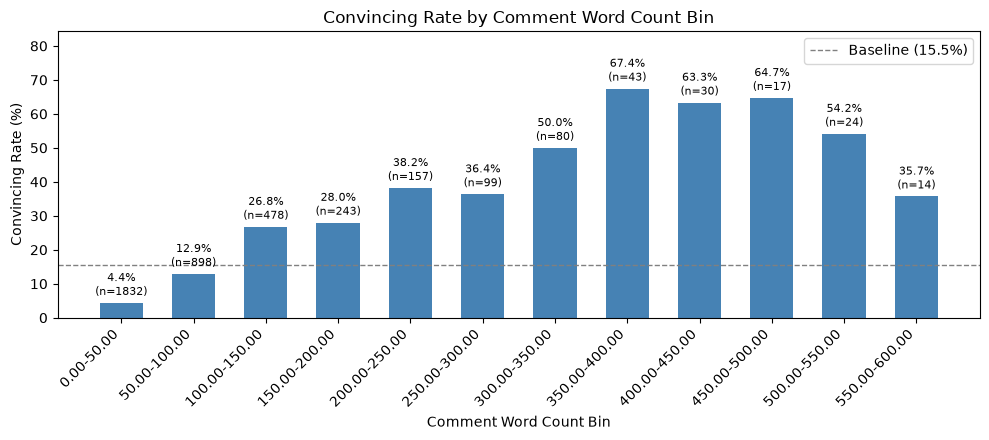

In [17]:
from common_functions import plot_feature

# Full range (0-1573 words) at this bin width would need ~80 bins - unreadable, and the tail
# beyond 600 words is thin enough (56 comments, 1.4%) that individual bins there are just
# noisy 0%/100% spikes. Restricting the chart to < 600 words (strict, not <=) keeps 98.6% of
# the data and shows the actual shape instead of a few near-empty tail bins dominating the
# view - strict so the 2 comments at exactly 600 words don't force an extra, near-empty
# '600-650' bin into existence just to hold them.
word_count_trimmed = comments_df[comments_df['word_count'] < 600]
print(f"{len(word_count_trimmed)} of {len(comments_df)} comments shown "
      f"({len(word_count_trimmed) / len(comments_df) * 100:.1f}%), "
      f"{len(comments_df) - len(word_count_trimmed)} excluded (>= 600 words)")

plot_feature(word_count_trimmed, 'word_count', 'Comment Word Count', bin_width=50, figsize=(10, 4.5))

Chart excludes the 56 comments (1.4%) at or beyond 600 words — each of those tail bins holds only 1-4 comments, producing 0%/100% spikes that swamp the actual trend rather than adding information.

In [18]:
# word_count alone, evaluated the same honest way as every other baseline in this notebook -
# thread-grouped train/test split, scaled (single continuous feature, same convention as the
# rest of the notebook's scaled variants).
word_count_train = comments_df['word_count'].iloc[train_idx].values.reshape(-1, 1)
word_count_test  = comments_df['word_count'].iloc[test_idx].values.reshape(-1, 1)

wc_scaler = RobustScaler()
word_count_train_scaled = wc_scaler.fit_transform(word_count_train)
word_count_test_scaled  = wc_scaler.transform(word_count_test)

wc_logreg = LogisticRegression(random_state=42, max_iter=1000)
wc_logreg.fit(word_count_train_scaled, y_train)
proba_wc = wc_logreg.predict_proba(word_count_test_scaled)[:, 1]
pred_wc  = wc_logreg.predict(word_count_test_scaled)

word_count_result = {
    'PR-AUC':  average_precision_score(y_test, proba_wc),
    'ROC-AUC': roc_auc_score(y_test, proba_wc),
    'F1':      f1_score(y_test, pred_wc, zero_division=0),
}

length_vs_others = pd.DataFrame({
    'word_count alone':             word_count_result,
    'TF-IDF alone':                 tfidf_alone,
    'Selected engineered pipeline': {'PR-AUC': pr_auc_selected, 'ROC-AUC': roc_auc_selected, 'F1': f1_selected},
}).T.round(4)
length_vs_others

,PR-AUC,ROC-AUC,F1
word_count alone,0.5256,0.8294,0.2105
TF-IDF alone,0.5119,0.8150,0.1235
Selected engineered pipeline,0.3848,0.6982,0.2513


**Length explains this well beyond "part of" TF-IDF's edge — it's a stronger predictor on its own than either model tried so far.** The correlation is strong and highly significant (r=0.3716, p≈3×10⁻¹³⁰), and the gap in means is large: convincing comments average 216.7 words vs. 78.0 for non-convincing ones — nearly 3x longer. But the more striking number is the predictive one: `word_count` **alone**, through a single-feature `LogisticRegression` evaluated on the exact same thread-grouped split as everything else in this notebook, reaches **PR-AUC 0.5256** — *ahead of* `TF-IDF + LogReg` (0.5119) and well ahead of the entire ~40-feature selected engineered pipeline (0.3848). One trivial number beats both a 5000-token bag-of-words model and the full feature-engineering effort from `03.1`-`03.3`.

**This reframes the headline finding of this notebook, not just qualifies it.** "TF-IDF beats engineered features" was already the surprising result driving this investigation — but if a huge share of TF-IDF's edge is really just picking up comment length, then the real story is closer to "comment length beats engineered features," with TF-IDF partially riding on that same signal (via the stopword-heavy tokens flagged above) rather than adding much rhetorical detection on top of it. That's a materially less interesting finding for a persuasion-detection project than the raw TF-IDF-vs-engineered-features comparison alone would suggest.

`word_count` is treated as a required baseline throughout this notebook from here on, not an optional addition, since a single length feature already outperforms both TF-IDF and the full engineered pipeline. The engineered feature set's underperformance looks worse in this light, too: it doesn't just lose to TF-IDF, it loses to a single line of code counting words — comment length was a real gap in `03.1`-`03.3`'s feature set, not a minor omission. That doesn't invalidate the `03.1`-`03.3` feature-engineering effort itself: the family ablation above still shows some engineered families (`ethos/pathos/logos`, `diff/match`) carry real, if small, standalone signal beyond length — and `04.3_length_controlled_analysis.ipynb` isolates exactly how much of that signal survives once length is controlled for directly, rather than assumed away.

### Is this a within-thread effect, or a hot-topics/thread-size artifact?

The correlation above is computed across the whole dataset, so it can't distinguish "longer comments are more persuasive" from "big, active threads (this dataset only samples Reddit's all-time top 500 posts, per `01_data_download.ipynb`) happen to have both longer winning comments and lots of short losing ones." Two within-thread checks isolate that, since holding thread identity fixed removes any effect that operates purely at the thread level (topic, thread size, how contentious the post is), leaving only the effect of a comment's length relative to its own thread.

In [19]:
from scipy.stats import pearsonr, wilcoxon

# Within-thread ("fixed effects") check: demean both word_count and is_convincing by thread,
# then correlate the demeaned values. This is the standard panel-data "within" estimator -
# mathematically equivalent to including a thread_id dummy in the regression - so it asks
# "holding thread identity (hence topic, hence thread size/popularity) constant, does word
# count still differ between convincing and non-convincing comments?" Threads with only one
# comment contribute exactly zero deviation and drop out of the estimate naturally.
thread_mean_wc   = comments_df.groupby('thread_id')['word_count'].transform('mean')
thread_mean_conv = comments_df.groupby('thread_id')['is_convincing'].transform('mean')

wc_within   = comments_df['word_count'] - thread_mean_wc
conv_within = comments_df['is_convincing'] - thread_mean_conv

r_within, p_within = pearsonr(wc_within, conv_within)
print(f'Within-thread (fixed-effects) correlation : r={r_within:.4f}, p={p_within:.2e}')
print(f'Across-dataset correlation (from above)    : r={r:.4f}, p={p:.2e}')

Within-thread (fixed-effects) correlation : r=0.2909, p=2.78e-78
Across-dataset correlation (from above)    : r=0.3716, p=2.92e-130


In [20]:
# Complementary, more intuitive view: for each thread containing at least one convincing and
# one non-convincing comment, compare their average word counts directly - a paired comparison
# that holds topic and thread activity level constant by construction, without the demeaning
# trick above. Threads with only convincing or only non-convincing comments can't be compared
# this way and are excluded (there's no "other side" within that thread to compare against).
thread_stats = comments_df.groupby('thread_id').agg(
    n_convincing=('is_convincing', 'sum'),
    n_total=('is_convincing', 'size'),
)
paired_threads = thread_stats[(thread_stats['n_convincing'] > 0) & (thread_stats['n_convincing'] < thread_stats['n_total'])].index

conv_mean     = comments_df[comments_df['is_convincing'] == 1].groupby('thread_id')['word_count'].mean()
non_conv_mean = comments_df[comments_df['is_convincing'] == 0].groupby('thread_id')['word_count'].mean()
paired_diff   = (conv_mean.loc[paired_threads] - non_conv_mean.loc[paired_threads])

print(f'Threads with both convincing and non-convincing comments: {len(paired_threads)} of {comments_df["thread_id"].nunique()}')
print(f'Convincing comment(s) longer than the thread\'s own non-convincing average: '
      f'{(paired_diff > 0).sum()} of {len(paired_diff)} threads ({(paired_diff > 0).mean() * 100:.1f}%)')
print(f'Mean within-thread difference (convincing - non-convincing)  : {paired_diff.mean():.1f} words')
print(f'Median within-thread difference                              : {paired_diff.median():.1f} words')

stat, p_wilcoxon = wilcoxon(paired_diff)
print(f'Wilcoxon signed-rank test (paired diff != 0): statistic={stat:.1f}, p={p_wilcoxon:.2e}')

Threads with both convincing and non-convincing comments: 200 of 401
Convincing comment(s) longer than the thread's own non-convincing average: 153 of 200 threads (76.5%)
Mean within-thread difference (convincing - non-convincing)  : 125.0 words
Median within-thread difference                              : 87.4 words
Wilcoxon signed-rank test (paired diff != 0): statistic=2729.0, p=4.15e-19


**The within-thread checks confirm this isn't a "hot topics" artifact — the effect survives holding thread identity fixed, on two independent tests.** The fixed-effects (demeaned) correlation drops from r=0.3716 across the whole dataset to r=0.2909 within threads — a real reduction, so *some* of the raw correlation genuinely is thread-level (bigger/more active threads do tend to have both longer winning comments and more short losing ones, exactly as hypothesized). But r=0.29 (p=2.78×10⁻⁷⁸) is still a strong, highly significant relationship *after* removing all of that — length still matters a lot even comparing only within the same thread.

**The paired comparison makes this concrete rather than statistical.** Of the 200 threads (out of 401) that have at least one comment on each side, the convincing comment is longer than that same thread's own non-convincing average in 153 of them — **76.5%** of the time — by a median of 87.4 words. A Wilcoxon signed-rank test rejects "no systematic within-thread difference" decisively (p=4.15×10⁻¹⁹). This is the most direct answer to the original question: even restricting the comparison to comments replying to the *same* post, in the *same* thread, on the *same* topic, at whatever level of activity that thread happened to reach — the comment that earns the delta is still usually the longer one.

**Conclusion on the open question**: downloading more/different data (e.g. adding `SORT_MODE='new'` posts alongside the current `'top'` sample) wouldn't have been the right next step here — it wouldn't have tested the hypothesis on its own, and the within-thread checks already test it more directly and far more cheaply. The length↔convincing relationship looks like a genuine property of what earns a delta on CMV, not primarily a sampling artifact of collecting only the all-time top 500 posts — consistent with Tan et al. 2016's similar finding on a much larger, non-top-500 sample. This strengthens rather than undercuts the earlier finding: `word_count` isn't a confound to explain away, it's a real signal, and belongs in future baselines as previously concluded.

### Follow-up: does removing stopwords reduce TF-IDF's reliance on length?

The token-coefficient check above found that many of `TF-IDF + LogReg`'s strongest "convincing" tokens are plain stopwords, plausibly because longer comments contain a broader set of them (`TfidfVectorizer` wasn't configured to strip stopwords). This refits `TF-IDF + LogReg` with English stopwords removed, on the same thread-grouped split, and checks two things: whether PR-AUC drops once that channel is closed off, and whether the model's predicted probabilities correlate less with `word_count` than the with-stopwords version's do.

In [21]:
tfidf_nostop = TfidfVectorizer(max_features=5000, min_df=2, stop_words='english')
X_text_train_nostop = tfidf_nostop.fit_transform(text_train)
X_text_test_nostop  = tfidf_nostop.transform(text_test)

tfidf_logreg_nostop = LogisticRegression(random_state=42, max_iter=1000)
tfidf_logreg_nostop.fit(X_text_train_nostop, y_train)
proba_nostop = tfidf_logreg_nostop.predict_proba(X_text_test_nostop)[:, 1]
pred_nostop  = tfidf_logreg_nostop.predict(X_text_test_nostop)

tfidf_nostop_result = {
    'PR-AUC':  average_precision_score(y_test, proba_nostop),
    'ROC-AUC': roc_auc_score(y_test, proba_nostop),
    'F1':      f1_score(y_test, pred_nostop, zero_division=0),
}

stopword_comparison = pd.DataFrame({
    'TF-IDF + LogReg (with stopwords)':    tfidf_alone,
    'TF-IDF + LogReg (stopwords removed)': tfidf_nostop_result,
}).T.round(4)
stopword_comparison

,PR-AUC,ROC-AUC,F1
TF-IDF + LogReg (with stopwords),0.5119,0.8150,0.1235
TF-IDF + LogReg (stopwords removed),0.4394,0.7644,0.0270


In [22]:
# Reuse tfidf_logreg/X_text_test (fit once in the Baselines section, never reassigned since) for
# a clean with-stopwords prediction, rather than relying on the ambient 'proba' scratch variable
# that later cells in this notebook repeatedly overwrite.
proba_with_stopwords = tfidf_logreg.predict_proba(X_text_test)[:, 1]
word_count_test_vals = comments_df['word_count'].iloc[test_idx].values

r_with_stopwords, p_with_stopwords = pearsonr(proba_with_stopwords, word_count_test_vals)
r_no_stopwords, p_no_stopwords     = pearsonr(proba_nostop, word_count_test_vals)

print('Correlation between predicted probability and word_count (test set):')
print(f'  TF-IDF + LogReg (with stopwords)    : r={r_with_stopwords:.4f}, p={p_with_stopwords:.2e}')
print(f'  TF-IDF + LogReg (stopwords removed) : r={r_no_stopwords:.4f}, p={p_no_stopwords:.2e}')

Correlation between predicted probability and word_count (test set):
  TF-IDF + LogReg (with stopwords)    : r=0.8433, p=8.43e-193
  TF-IDF + LogReg (stopwords removed) : r=0.7417, p=9.29e-125


In [23]:
coef_df_nostop = pd.DataFrame({
    'token':       tfidf_nostop.get_feature_names_out(),
    'coefficient': tfidf_logreg_nostop.coef_[0],
})
top_convincing_nostop = coef_df_nostop.sort_values('coefficient', ascending=False).head(n_top).reset_index(drop=True)
top_convincing_nostop

,token,coefficient
0,people,2.097264
1,edit,2.062511
2,lot,1.609521
3,doesnt,1.500169
4,israel,1.460991
5,platform,1.363152
6,gun,1.311353
7,body,1.238221
8,going,1.234558
9,look,1.216106


**Removing stopwords weakens TF-IDF's tie to length, but only partially.** The correlation between the model's predicted probability and `word_count` drops from r=0.8433 (with stopwords) to r=0.7417 (stopwords removed) — a real reduction, confirming that stopword coverage was one channel carrying length into TF-IDF's predictions. But both numbers are far higher than the raw `word_count`-vs-`is_convincing` correlation established earlier (r=0.3716): TF-IDF's predictions lean on length far more heavily than the underlying label itself does, with or without stopwords in the vocabulary.

**Stopword removal is a net loss on the metrics that matter, though.** PR-AUC drops from 0.5119 to 0.4394 (-0.0725), ROC-AUC from 0.8150 to 0.7644, and F1 nearly collapses (0.1235 → 0.0270). Whatever length-proxy role stopwords were playing, they were also carrying real predictive signal that a plain English-stopword list doesn't cleanly separate from noise — removing them doesn't isolate "genuine rhetoric" from "length artifact"; it removes a large share of what the model was using to predict at all.

**The new top tokens show the channel didn't close, it moved.** With stopwords gone, the top positive tokens are `people`, `edit`, `lot`, `doesnt`, `israel`, `platform`, `gun`, `going`, `look`, `think` — `edit` (already flagged above as a likely artifact) and several thread/topic-specific words (`israel`, `gun`, `school`, `culture`, `insurance`, `lawyers`) persist, alongside generic everyday words (`people`, `lot`, `doesnt`, `going`, `look`, `think`) that aren't on the standard English stopword list but plausibly still track comment length and elaboration the same way stopwords did. `x200b` — a leftover Reddit zero-width-space artifact — appears here as a new token, unrelated to the length question this section is investigating.

**Decision: TF-IDF keeps stopwords in, for the rest of this notebook and beyond.** Removing them costs real predictive power (PR-AUC 0.5119 → 0.4394, F1 0.1235 → 0.0270) without meaningfully closing the length gap (r=0.8433 → 0.7417, still far above the raw label's own r=0.3716) — so the with-stopwords baseline from the Baselines section above is the one carried forward.

### Follow-up: stacking the best trusted and untrusted families together

Both ablations above found a small "best pair" that beats TF-IDF alone: `ethos/pathos/logos` + `diff/match` among the trusted families (+0.0116 PR-AUC), and `sentiment (untrusted)` + `tone/style (untrusted)` among the untrusted ones (+0.0042). Each pair was tested within its own family set. This checks whether the two winning pairs compound when stacked together on top of each other — and then, since `word_count` alone already outperforms every family and combination tried in this notebook (PR-AUC 0.5256), whether it adds anything further stacked on top of all four. Building the same cumulative view one more time, starting from TF-IDF alone and adding, in order: `ethos/pathos/logos` (trusted), `diff/match` (trusted), `sentiment (untrusted)`, `tone/style (untrusted)`, `word_count`.

In [24]:
# X_with_untrusted doesn't include word_count (a comments_df column, not an engineered/
# untrusted feature) - build a source_df that adds it in for this one chain, so word_count
# can slot into the same evaluate_tfidf_plus_features(..., source_df=...) convention as
# everything else above.
X_with_untrusted_and_wc = pd.concat([X_with_untrusted, comments_df[['word_count']]], axis=1)

combined_steps = [
    ('ethos/pathos/logos',     FEATURE_FAMILIES['ethos/pathos/logos']),
    ('diff/match',             FEATURE_FAMILIES['diff/match']),
    ('sentiment (untrusted)',  UNTRUSTED_FAMILIES['sentiment (untrusted)']),
    ('tone/style (untrusted)', UNTRUSTED_FAMILIES['tone/style (untrusted)']),
    ('word_count',             ['word_count']),
]

combined_results = {'TF-IDF alone': tfidf_alone}
combined_cols = []
for label, cols in combined_steps:
    combined_cols = combined_cols + cols
    combined_results[f'+ {label}'] = evaluate_tfidf_plus_features(combined_cols, source_df=X_with_untrusted_and_wc)

combined_df = pd.DataFrame(combined_results).T.round(4)
combined_df['Delta PR-AUC vs previous row'] = combined_df['PR-AUC'].diff().round(4)
combined_df

,PR-AUC,ROC-AUC,F1,Delta PR-AUC vs previous row
TF-IDF alone,0.5119,0.8150,0.1235,NaN
+ ethos/pathos/logos,0.5221,0.8151,0.1595,0.0102
+ diff/match,0.5235,0.8064,0.2143,0.0014
+ sentiment (untrusted),0.5279,0.8082,0.1928,0.0044
+ tone/style (untrusted),0.5311,0.8052,0.2024,0.0032
+ word_count,0.5351,0.8131,0.2500,0.0040


**`word_count` adds real signal even stacked on top of the strongest combination found so far.** Adding it as a fifth step pushes PR-AUC from 0.5311 to 0.5351 (+0.0040) — a smaller increment than the earlier steps, but still a genuine gain, not noise the way some individual families' later additions were in the ablations above. ROC-AUC recovers too (0.8052 → 0.8131, close to TF-IDF alone's 0.8150), and F1 reaches 0.2500, the best of any step in this chain — the first time in this section a metric improves at every single step rather than trading PR-AUC gains for ROC-AUC losses.

**The total lift over TF-IDF alone is now +0.0232 PR-AUC**, with all five features combined (`ethos/pathos/logos`, `diff/match`, `sentiment (untrusted)`, `tone/style (untrusted)`, `word_count`) reaching 0.5351 versus TF-IDF's 0.5119 — the strongest result anywhere in this notebook. `word_count` still carries distinct signal beyond what these five features already capture together, consistent with it beating every one of them individually earlier in this notebook.

## 8.10 Stacked Ensemble (TF-IDF + Engineered Features, Blended)

Most naive concatenations tried above landed at or below TF-IDF alone — the full engineered set, most individual trusted families (`OP features` worst of all), and any trusted combination past the best two. The one trusted combination that beat TF-IDF alone was the best-looking pair, `ethos/pathos/logos` + `diff/match` (+0.0116 PR-AUC) — but that gain didn't extend further; every family added past those two gave some of it back. The untrusted features behaved a little differently: every combination tried, solo or cumulative, landed at or slightly above TF-IDF alone, peaking at +0.0042 with two families and settling at +0.0033 for all three combined — genuinely small, but never a net loss the way most trusted combinations were. Either way, the shape is the same: a modest peak at one or two families, then flat-to-declining returns as more are stacked into the same shared, L2-regularized objective, where they compete with TF-IDF's own signal rather than adding to it cleanly.

This section tries a different combination strategy: train TF-IDF+LR and the selected engineered pipeline (`selected_pipe`: XGB + SMOTE oversampling on `trusted+untrusted`) completely separately, each on its own natural representation, then blend their predicted probabilities. The blend weight is chosen on a held-out validation split — the same thread-grouped inner-train/validation split `04.1_model_training.ipynb` already uses for threshold tuning — rather than a fresh k-fold cross-validation scheme, since fitting one or two parameters doesn't need more data than that split already provides. Two combiners are tried and the better one (on validation) is carried to the test set: a single fixed blend weight, and a small logistic-regression meta-model over both models' probabilities.

In [25]:
# Same thread-grouped inner-train/validation split as 04.1_model_training.ipynb's threshold
# tuning (same random_state=0), reproduced here rather than depending on that notebook having
# been run - inner_idx/val_idx are positions relative to train_idx, not absolute row positions.
train_groups = groups.iloc[train_idx].reset_index(drop=True)
y_train_r    = y_train.reset_index(drop=True)

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=0)
inner_idx, val_idx = next(gss_val.split(np.zeros((len(train_idx), 1)), y_train_r, groups=train_groups))

y_inner = y_train_r.iloc[inner_idx]
y_val   = y_train_r.iloc[val_idx]

inner_threads = set(train_groups.iloc[inner_idx])
val_threads   = set(train_groups.iloc[val_idx])
assert len(inner_threads & val_threads) == 0
print(f'Inner train: {len(inner_idx)} comments from {len(inner_threads)} threads')
print(f'Validation : {len(val_idx)} comments from {len(val_threads)} threads')

Inner train: 2629 comments from 256 threads
Validation : 633 comments from 64 threads


In [26]:
# TF-IDF + LogReg, fit on inner only (not the full training set) so its validation-set
# predictions are genuinely out-of-sample - needed to pick a blend weight honestly.
text_inner = text_train.iloc[inner_idx]
text_val   = text_train.iloc[val_idx]

tfidf_inner = TfidfVectorizer(max_features=5000, min_df=2)
X_text_inner_fit = tfidf_inner.fit_transform(text_inner)
X_text_val_fit   = tfidf_inner.transform(text_val)

tfidf_logreg_inner = LogisticRegression(random_state=42, max_iter=1000)
tfidf_logreg_inner.fit(X_text_inner_fit, y_inner)
proba_tfidf_val = tfidf_logreg_inner.predict_proba(X_text_val_fit)[:, 1]

# Engineered pipeline - same architecture as selected_pipe above - fit on inner only.
X_train_selected_inner = X_train_selected.iloc[inner_idx]
X_train_selected_val   = X_train_selected.iloc[val_idx]

eng_pipe_inner = Pipeline([
    ('scaler', RobustScaler()),
    ('sampler', SMOTE(random_state=42)),
    ('clf', xgb.XGBClassifier(random_state=42, eval_metric='logloss')),
])
eng_pipe_inner.fit(X_train_selected_inner, y_inner)
proba_eng_val = eng_pipe_inner.predict_proba(X_train_selected_val)[:, 1]

print(f'TF-IDF (inner-fit) val PR-AUC     : {average_precision_score(y_val, proba_tfidf_val):.4f}')
print(f'Engineered (inner-fit) val PR-AUC : {average_precision_score(y_val, proba_eng_val):.4f}')

TF-IDF (inner-fit) val PR-AUC     : 0.3971
Engineered (inner-fit) val PR-AUC : 0.3063


In [27]:
alphas = np.linspace(0, 1, 101)
alpha_scores = [
    average_precision_score(y_val, a * proba_tfidf_val + (1 - a) * proba_eng_val)
    for a in alphas
]
best_alpha = alphas[int(np.argmax(alpha_scores))]
best_alpha_pr_auc = max(alpha_scores)

print(f'Best blend weight (alpha, TF-IDF share): {best_alpha:.2f}')
print(f'Validation PR-AUC at that weight: {best_alpha_pr_auc:.4f}')
print(f'  (TF-IDF alone on val: {average_precision_score(y_val, proba_tfidf_val):.4f},'
      f' engineered alone on val: {average_precision_score(y_val, proba_eng_val):.4f})')

Best blend weight (alpha, TF-IDF share): 0.83
Validation PR-AUC at that weight: 0.4099
  (TF-IDF alone on val: 0.3971, engineered alone on val: 0.3063)


In [28]:
meta_X_val = np.column_stack([proba_tfidf_val, proba_eng_val])
meta_logreg = LogisticRegression(random_state=42)
meta_logreg.fit(meta_X_val, y_val)
meta_proba_val = meta_logreg.predict_proba(meta_X_val)[:, 1]
meta_pr_auc_val = average_precision_score(y_val, meta_proba_val)

# Both the alpha search and this meta-model were fit and scored on the same validation set -
# a fair head-to-head, since both have equally little capacity to overfit it (1 parameter vs.
# 2 coefficients + intercept). Test remains untouched by either choice made here.
use_meta_logreg = meta_pr_auc_val > best_alpha_pr_auc

print(f'Learned LR meta-combiner val PR-AUC: {meta_pr_auc_val:.4f}  (fixed-alpha blend: {best_alpha_pr_auc:.4f})')
print(f'Selected combiner for test evaluation: {"learned LR meta-model" if use_meta_logreg else f"fixed blend (alpha={best_alpha:.2f})"}')

Learned LR meta-combiner val PR-AUC: 0.4020  (fixed-alpha blend: 0.4099)
Selected combiner for test evaluation: fixed blend (alpha=0.83)


In [29]:
# Base-model test-set probabilities, from the pipelines already fit on the FULL training set
# above (tfidf_logreg in the Baselines section, selected_pipe in the Reference Point section) -
# not the inner-only fits used above, which existed only to pick the combiner honestly.
proba_tfidf_test = tfidf_logreg.predict_proba(X_text_test)[:, 1]
proba_eng_test   = selected_pipe.predict_proba(X_test_selected)[:, 1]

if use_meta_logreg:
    meta_X_test = np.column_stack([proba_tfidf_test, proba_eng_test])
    proba_stacked_test = meta_logreg.predict_proba(meta_X_test)[:, 1]
else:
    proba_stacked_test = best_alpha * proba_tfidf_test + (1 - best_alpha) * proba_eng_test

pred_stacked_test = (proba_stacked_test >= 0.5).astype(int)

stacked_result = {
    'PR-AUC':  average_precision_score(y_test, proba_stacked_test),
    'ROC-AUC': roc_auc_score(y_test, proba_stacked_test),
    'F1':      f1_score(y_test, pred_stacked_test, zero_division=0),
}

stacking_comparison = pd.DataFrame({
    'TF-IDF alone':                 tfidf_alone,
    'Selected engineered pipeline': {'PR-AUC': pr_auc_selected, 'ROC-AUC': roc_auc_selected, 'F1': f1_selected},
    'Stacked (blended)':            stacked_result,
}).T.round(4)
stacking_comparison

,PR-AUC,ROC-AUC,F1
TF-IDF alone,0.5119,0.8150,0.1235
Selected engineered pipeline,0.3848,0.6982,0.2513
Stacked (blended),0.5152,0.8093,0.1366


In [30]:
def bootstrap_ci(y_true, proba, metric_fn, n_boot=1000, seed=42):
    """95% CI for a metric_fn(y_true_sample, proba_sample) via resampling with replacement."""
    rng = np.random.RandomState(seed)
    y_true = np.asarray(y_true)
    proba  = np.asarray(proba)
    n = len(y_true)
    scores = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        yt, pb = y_true[idx], proba[idx]
        if len(np.unique(yt)) < 2:
            continue
        scores.append(metric_fn(yt, pb))
    return np.percentile(scores, 2.5), np.percentile(scores, 97.5)

ci_tfidf   = bootstrap_ci(y_test, proba_tfidf_test, average_precision_score)
ci_eng     = bootstrap_ci(y_test, proba_eng_test, average_precision_score)
ci_stacked = bootstrap_ci(y_test, proba_stacked_test, average_precision_score)

pr_auc_ci_comparison = pd.DataFrame({
    'PR-AUC':        [tfidf_alone['PR-AUC'], pr_auc_selected, stacked_result['PR-AUC']],
    'PR-AUC 95% CI': [ci_tfidf, ci_eng, ci_stacked],
}, index=['TF-IDF alone', 'Selected engineered pipeline', 'Stacked (blended)'])
pr_auc_ci_comparison

,PR-AUC,PR-AUC 95% CI
TF-IDF alone,0.511861,"(0.4296995810391229, 0.6031731987916423)"
Selected engineered pipeline,0.384771,"(0.3114300838772552, 0.4629195832057603)"
Stacked (blended),0.515226,"(0.433401803099745, 0.6049344980448894)"


**The fixed-weight blend beat the learned meta-model on validation** — 0.4099 PR-AUC vs. 0.4020 — so it's the one carried to the test set, at `alpha = 0.83` (83% TF-IDF, 17% engineered). That weight itself is informative: it's close to what the two models' relative validation strength would suggest (TF-IDF alone: 0.3971, engineered alone: 0.3063), rather than an even split — the search correctly leaned hard toward the stronger model instead of averaging them naively.

**On the test set, stacking edges out TF-IDF alone** — PR-AUC 0.5152 vs. 0.5119 (+0.0033), F1 0.1366 vs. 0.1235 (+0.0131) — while ROC-AUC is essentially flat (0.8093 vs. 0.8150). This is a genuinely different outcome from every naive-concatenation attempt above, all of which landed *below* TF-IDF alone (the best of those, `TF-IDF + scalar features only`, still trailed by -0.0462 PR-AUC). Separating the two models and blending their probabilities, rather than forcing both representations through one shared objective, is the first approach in this notebook that doesn't cost PR-AUC relative to TF-IDF alone.

**But the bootstrap CIs make clear this isn't a confident win.** TF-IDF alone's PR-AUC 95% CI is [0.430, 0.603]; the stacked blend's is [0.433, 0.605] — almost the same interval, just shifted by the same +0.003 as the point estimate. A gain this small, on a test set this size (709 comments, 81 threads), is well within the noise floor already established elsewhere in this project (recall the leakage comparison in `04.1_model_training.ipynb` couldn't distinguish two PR-AUC estimates 0.03 apart with overlapping CIs).

**Bottom line**: stacking validates the underlying hypothesis — the engineered features *can* be combined with TF-IDF without hurting it, once the two representations stop competing inside the same regularized fit — but it doesn't produce a result clearly better than using TF-IDF alone. Given how heavily the optimal blend leans toward TF-IDF (`alpha = 0.83`) and how weak the engineered pipeline is standalone (PR-AUC 0.3848 vs. TF-IDF's 0.5119), that's not surprising: there's a real ceiling on how much a much weaker model can lift a much stronger one through blending alone, however cleanly it's combined. A stronger engineered-features model (rather than a better combination strategy) looks like the more promising next lever — which points back to the original plan of trying rhetorical-strategy scores (MS-PS framework) or task-focused embeddings (e5) as **new** signal, rather than further recombination of what's already been tried.

## Main-Track Length Comparisons on the ≥30-Word Working Dataset

Every comparison so far in this notebook used the full dataset. But per the 2026-08-15 email exchange (`PLAN.md` 1.9), the working dataset going forward is the ≥30-word floor established in `04.3_length_controlled_analysis.ipynb` §8.13 — and on that dataset, length is treated as a *legitimate* feature rather than a confound to strip out. This re-runs the core reference points (length-only, TF-IDF-only, engineered-only) on that floor rather than the full dataset used everywhere above, and adds two combinations not tested anywhere else in this notebook: `length + TF-IDF` and `length + engineered`.

In [31]:
content_mask = (comments_df['is_convincing'] == 1) | (comments_df['word_count'] >= 30)
comments_df_30floor = comments_df[content_mask].copy()

print(f'>=30-word working dataset: {len(comments_df_30floor)} comments '
      f'({int(comments_df_30floor["is_convincing"].sum())} convincing, '
      f'positive rate {comments_df_30floor["is_convincing"].mean():.3f}) - vs. '
      f'{len(comments_df)} / {int(comments_df["is_convincing"].sum())} / '
      f'{comments_df["is_convincing"].mean():.3f} in the full dataset')

>=30-word working dataset: 2753 comments (641 convincing, positive rate 0.233) - vs. 3971 / 641 / 0.161 in the full dataset


In [32]:
floor_idx    = comments_df_30floor.index
y_floor      = comments_df.loc[floor_idx, 'is_convincing']
groups_floor = comments_df.loc[floor_idx, 'thread_id']

gss_floor = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_pos, te_pos = next(gss_floor.split(np.zeros((len(floor_idx), 1)), y_floor, groups=groups_floor))
train_idx_floor, test_idx_floor = floor_idx[tr_pos], floor_idx[te_pos]

y_train_floor, y_test_floor = y_floor.loc[train_idx_floor], y_floor.loc[test_idx_floor]

train_threads_floor = set(groups_floor.loc[train_idx_floor])
test_threads_floor  = set(groups_floor.loc[test_idx_floor])
assert len(train_threads_floor & test_threads_floor) == 0, 'LEAKAGE: shared threads between train and test!'
print(f'Train: {len(train_idx_floor)} comments from {len(train_threads_floor)} threads')
print(f'Test : {len(test_idx_floor)} comments from {len(test_threads_floor)} threads')

Train: 2161 comments from 320 threads
Test : 592 comments from 80 threads


In [33]:
text_train_floor = comments_df.loc[train_idx_floor, 'cleaned_final_comment'].fillna('')
text_test_floor  = comments_df.loc[test_idx_floor, 'cleaned_final_comment'].fillna('')

tfidf_floor = TfidfVectorizer(max_features=5000, min_df=2)
X_text_train_floor = tfidf_floor.fit_transform(text_train_floor)
X_text_test_floor  = tfidf_floor.transform(text_test_floor)

tfidf_logreg_floor = LogisticRegression(random_state=42, max_iter=1000)
tfidf_logreg_floor.fit(X_text_train_floor, y_train_floor)
proba_tfidf_floor = tfidf_logreg_floor.predict_proba(X_text_test_floor)[:, 1]
pred_tfidf_floor  = tfidf_logreg_floor.predict(X_text_test_floor)

tfidf_floor_result = {
    'PR-AUC':  average_precision_score(y_test_floor, proba_tfidf_floor),
    'ROC-AUC': roc_auc_score(y_test_floor, proba_tfidf_floor),
    'F1':      f1_score(y_test_floor, pred_tfidf_floor, zero_division=0),
}

In [34]:
wc_train_floor = comments_df.loc[train_idx_floor, ['word_count']].values
wc_test_floor  = comments_df.loc[test_idx_floor, ['word_count']].values

wc_scaler_floor = RobustScaler()
wc_train_floor_scaled = wc_scaler_floor.fit_transform(wc_train_floor)
wc_test_floor_scaled  = wc_scaler_floor.transform(wc_test_floor)

wc_logreg_floor = LogisticRegression(random_state=42, max_iter=1000)
wc_logreg_floor.fit(wc_train_floor_scaled, y_train_floor)
proba_wc_floor = wc_logreg_floor.predict_proba(wc_test_floor_scaled)[:, 1]
pred_wc_floor  = wc_logreg_floor.predict(wc_test_floor_scaled)

wc_floor_result = {
    'PR-AUC':  average_precision_score(y_test_floor, proba_wc_floor),
    'ROC-AUC': roc_auc_score(y_test_floor, proba_wc_floor),
    'F1':      f1_score(y_test_floor, pred_wc_floor, zero_division=0),
}

In [35]:
X_eng_train_floor = X_with_untrusted.loc[train_idx_floor]
X_eng_test_floor  = X_with_untrusted.loc[test_idx_floor]

eng_pipe_floor = Pipeline([
    ('scaler', RobustScaler()),
    ('sampler', SMOTE(random_state=42)),
    ('clf', xgb.XGBClassifier(random_state=42, eval_metric='logloss')),
])
eng_pipe_floor.fit(X_eng_train_floor, y_train_floor)
proba_eng_floor = eng_pipe_floor.predict_proba(X_eng_test_floor)[:, 1]
pred_eng_floor  = eng_pipe_floor.predict(X_eng_test_floor)

eng_floor_result = {
    'PR-AUC':  average_precision_score(y_test_floor, proba_eng_floor),
    'ROC-AUC': roc_auc_score(y_test_floor, proba_eng_floor),
    'F1':      f1_score(y_test_floor, pred_eng_floor, zero_division=0),
}

reference_points_floor = pd.DataFrame({
    'TF-IDF only':     tfidf_floor_result,
    'Length only':     wc_floor_result,
    'Engineered only': eng_floor_result,
}).T.round(4)
reference_points_floor

,PR-AUC,ROC-AUC,F1
TF-IDF only,0.3905,0.6617,0.0784
Length only,0.4528,0.7165,0.1905
Engineered only,0.2975,0.5681,0.2443


In [36]:
# Unscaled concatenation - TF-IDF's own vectors are already L2-normalized, and every scaled
# combination attempt in §8.7 underperformed the unscaled version, so this matches that
# established convention rather than scaling word_count before stacking it on.
wc_train_floor_raw = csr_matrix(comments_df.loc[train_idx_floor, ['word_count']].values)
wc_test_floor_raw  = csr_matrix(comments_df.loc[test_idx_floor, ['word_count']].values)

X_combo_train_floor = hstack([X_text_train_floor, wc_train_floor_raw])
X_combo_test_floor  = hstack([X_text_test_floor, wc_test_floor_raw])

combo_logreg_floor = LogisticRegression(random_state=42, max_iter=1000)
combo_logreg_floor.fit(X_combo_train_floor, y_train_floor)
proba_combo_floor = combo_logreg_floor.predict_proba(X_combo_test_floor)[:, 1]
pred_combo_floor  = combo_logreg_floor.predict(X_combo_test_floor)

length_tfidf_result = {
    'PR-AUC':  average_precision_score(y_test_floor, proba_combo_floor),
    'ROC-AUC': roc_auc_score(y_test_floor, proba_combo_floor),
    'F1':      f1_score(y_test_floor, pred_combo_floor, zero_division=0),
}

In [37]:
# word_count added as one more column alongside the rest of X_with_untrusted, scaled by the
# same RobustScaler step as every other column in this pipeline - consistent with how the
# engineered pipeline already treats its other raw-scale columns (e.g. fk_grade_level).
X_with_untrusted_and_wc_floor_train = pd.concat([
    X_with_untrusted.loc[train_idx_floor], comments_df.loc[train_idx_floor, ['word_count']]
], axis=1)
X_with_untrusted_and_wc_floor_test = pd.concat([
    X_with_untrusted.loc[test_idx_floor], comments_df.loc[test_idx_floor, ['word_count']]
], axis=1)

length_eng_pipe = Pipeline([
    ('scaler', RobustScaler()),
    ('sampler', SMOTE(random_state=42)),
    ('clf', xgb.XGBClassifier(random_state=42, eval_metric='logloss')),
])
length_eng_pipe.fit(X_with_untrusted_and_wc_floor_train, y_train_floor)
proba_length_eng = length_eng_pipe.predict_proba(X_with_untrusted_and_wc_floor_test)[:, 1]
pred_length_eng  = length_eng_pipe.predict(X_with_untrusted_and_wc_floor_test)

length_engineered_result = {
    'PR-AUC':  average_precision_score(y_test_floor, proba_length_eng),
    'ROC-AUC': roc_auc_score(y_test_floor, proba_length_eng),
    'F1':      f1_score(y_test_floor, pred_length_eng, zero_division=0),
}

In [38]:
main_track_summary = pd.DataFrame({
    'Length only':         wc_floor_result,
    'TF-IDF only':         tfidf_floor_result,
    'Engineered only':     eng_floor_result,
    'Length + TF-IDF':     length_tfidf_result,
    'Length + Engineered': length_engineered_result,
}).T.round(4)
main_track_summary

,PR-AUC,ROC-AUC,F1
Length only,0.4528,0.7165,0.1905
TF-IDF only,0.3905,0.6617,0.0784
Engineered only,0.2975,0.5681,0.2443
Length + TF-IDF,0.4327,0.7009,0.1677
Length + Engineered,0.4828,0.7441,0.4473


In [39]:
# The test-fold's own positive rate (not the whole-sample rate) is the correct no-skill
# PR-AUC baseline for this split - see 04.3_length_controlled_analysis.ipynb §8.11 for why
# this distinction matters on a filtered, non-standard-sized sample like this one.
test_positive_rate_floor = y_test_floor.mean()
print(f'Test-fold positive rate (no-skill baseline): {test_positive_rate_floor:.4f}')

main_track_lift = main_track_summary.copy()
main_track_lift['Lift over no-skill'] = (main_track_lift['PR-AUC'] - test_positive_rate_floor).round(4)
main_track_lift

Test-fold positive rate (no-skill baseline): 0.2382


,PR-AUC,ROC-AUC,F1,Lift over no-skill
Length only,0.4528,0.7165,0.1905,0.2146
TF-IDF only,0.3905,0.6617,0.0784,0.1523
Engineered only,0.2975,0.5681,0.2443,0.0593
Length + TF-IDF,0.4327,0.7009,0.1677,0.1945
Length + Engineered,0.4828,0.7441,0.4473,0.2446


**Length is still the strongest single feature on this dataset, and by a wider margin than on the full dataset.** `Length only` reaches 0.4528 PR-AUC (+0.2146 over the 0.2382 no-skill baseline), ahead of `TF-IDF only` (0.3905, +0.1523) and well ahead of `Engineered only` (0.2975, +0.0593) — the same ranking (length > TF-IDF > engineered) as on the full dataset above, but with a bigger gap between length and TF-IDF here (0.0623 vs. 0.0137 on the full dataset). Every number here is lower than its full-dataset counterpart, which is expected: removing the shortest, most trivially-non-convincing comments removes some of the easiest cases for every model, and the positive rate itself shifts (16.1% → 23.8%), so these aren't directly comparable to the full-dataset numbers without accounting for the different no-skill baseline — the `Lift over no-skill` column is the fair comparison.

**The two combinations behave in opposite directions.** `Length + TF-IDF` (0.4327, naive unscaled concatenation into one LogReg) actually *underperforms* `Length only` (0.4528) — the same failure mode naive concatenation showed repeatedly in §8.7-8.8, now reproduced with length as one of the two inputs instead of an engineered feature family. `Length + Engineered` (0.4828, word_count added as one more column into the scaled XGB+SMOTE pipeline) is the opposite story: it clearly beats both `Length only` and `Engineered only`, and is the best result anywhere in this section — including the best F1 by a wide margin (0.4473, more than double every other row here). Whatever made naive LogReg concatenation with TF-IDF a poor combination strategy throughout this notebook doesn't apply here — folding length into the engineered pipeline's own scaled, tree-based architecture works cleanly.

**Bottom line**: on the working dataset Move 2 will actually use, length remains the dominant single signal, and the one combination that reliably improves on it is length stacked into the engineered feature set — not length stacked onto TF-IDF. That's a specific, concrete argument for including `word_count` directly in the engineered feature matrix (`X`/`X_with_untrusted`) going forward, not just testing it as a separate reference point.

## Re-Running Model Selection with `word_count` Included

Everything above treats `word_count` as a variable of interest, not as a candidate feature — the model-selection grid that chose the pipeline reproduced in this notebook's Reference Point section (`04.1_model_training.ipynb`) ran before this signal was known. This reruns that same validation-grid methodology (9 classifiers × 3 resampling strategies × 3 feature sets) self-contained, here, with `word_count` added to the `trusted`/`trusted+untrusted` feature sets, to check whether model selection itself would change now that the strongest single signal found in this notebook is actually available to it — the same kind of self-contained re-selection check `04.3_length_controlled_analysis.ipynb` (§8.12) already does for its length-matched sample.

In [40]:
# Same construction as X/X_with_untrusted above, plus word_count - new variable names
# throughout (the _wc suffix) so nothing here touches X, X_with_untrusted, or
# tfidf_alone/pr_auc_selected, which the rest of this notebook uses as fixed reference points.
numeric_features_wc = numeric_features + ['word_count']

X_wc = pd.concat([tone_df,
                  comments_df[['is_formal', 'is_formal_op', 'use_of_persuasive_lang'] + numeric_features_wc],
                  match_df,
                  comments_df[embedding_features]],
                 axis=1)

X_with_untrusted_wc = pd.concat([X_wc] + untrusted_encoded, axis=1)

feature_sets_wc = {
    'trusted':           X_wc,
    'trusted+untrusted': X_with_untrusted_wc,
    'embeddings-only':   X[embedding_features],
}
print({name: f'{fs.shape[1]} features' for name, fs in feature_sets_wc.items()})

{'trusted': '229 features', 'trusted+untrusted': '240 features', 'embeddings-only': '187 features'}


In [41]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.under_sampling import RandomUnderSampler

def make_pipelines_wc(clf, resampling='none'):
    steps = [('scaler', RobustScaler())]
    if resampling == 'under':
        steps.append(('sampler', RandomUnderSampler(random_state=42)))
    elif resampling == 'over':
        steps.append(('sampler', SMOTE(random_state=42)))
    steps.append(('clf', clf))
    return Pipeline(steps)

pipelines_wc = {
    'LogReg (none)':  make_pipelines_wc(LogisticRegression(random_state=42, max_iter=1000), 'none'),
    'LogReg (under)': make_pipelines_wc(LogisticRegression(random_state=42, max_iter=1000), 'under'),
    'LogReg (over)':  make_pipelines_wc(LogisticRegression(random_state=42, max_iter=1000), 'over'),
    'RF (none)':      make_pipelines_wc(RandomForestClassifier(random_state=42, n_estimators=100), 'none'),
    'RF (under)':     make_pipelines_wc(RandomForestClassifier(random_state=42, n_estimators=100), 'under'),
    'RF (over)':      make_pipelines_wc(RandomForestClassifier(random_state=42, n_estimators=100), 'over'),
    'XGB (none)':     make_pipelines_wc(xgb.XGBClassifier(random_state=42, eval_metric='logloss'), 'none'),
    'XGB (under)':    make_pipelines_wc(xgb.XGBClassifier(random_state=42, eval_metric='logloss'), 'under'),
    'XGB (over)':     make_pipelines_wc(xgb.XGBClassifier(random_state=42, eval_metric='logloss'), 'over'),
}
print(f'{len(pipelines_wc)} pipelines defined')

9 pipelines defined


In [42]:
# Thread-disjoint inner-train/validation split, carved from train_idx - mirrors
# 04.1_model_training.ipynb's approach (same random_state=0), so model selection never
# touches the held-out test set. train_idx/test_idx themselves are reused as-is from this
# notebook's Setup - word_count adds a column, not a row, so the same split still applies.
train_groups_wc = groups.iloc[train_idx].reset_index(drop=True)
y_train_wc_r    = y_train.reset_index(drop=True)

gss_val_wc = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=0)
inner_pos, val_pos = next(gss_val_wc.split(np.zeros((len(train_idx), 1)), y_train_wc_r, groups=train_groups_wc))

inner_idx_wc = np.array(train_idx)[inner_pos]
val_idx_wc   = np.array(train_idx)[val_pos]

y_inner_wc = y.loc[inner_idx_wc]
y_val_wc   = y.loc[val_idx_wc]

inner_threads_wc = set(groups.loc[inner_idx_wc])
val_threads_wc   = set(groups.loc[val_idx_wc])
assert len(inner_threads_wc & val_threads_wc) == 0
print(f'Inner train     : {len(inner_idx_wc)} comments from {len(inner_threads_wc)} threads')
print(f'Validation      : {len(val_idx_wc)} comments from {len(val_threads_wc)} threads')
print(f'Test (held out) : {len(test_idx)} comments from {groups.loc[test_idx].nunique()} threads')

Inner train     : 2629 comments from 256 threads
Validation      : 633 comments from 64 threads
Test (held out) : 709 comments from 81 threads


In [43]:
val_metrics_wc  = {}
combo_lookup_wc = {}

for fs_name, X_variant in feature_sets_wc.items():
    X_inner_variant = X_variant.loc[inner_idx_wc]
    X_val_variant   = X_variant.loc[val_idx_wc]

    for model_name, pipe in pipelines_wc.items():
        combo_name = f'{model_name} | {fs_name}'
        pipe.fit(X_inner_variant, y_inner_wc)
        proba_val = pipe.predict_proba(X_val_variant)[:, 1]

        val_metrics_wc[combo_name] = {
            'PR-AUC':  round(average_precision_score(y_val_wc, proba_val), 4),
            'ROC-AUC': round(roc_auc_score(y_val_wc, proba_val), 4),
        }
        combo_lookup_wc[combo_name] = (model_name, fs_name)

val_df_wc = pd.DataFrame(val_metrics_wc).T.sort_values('PR-AUC', ascending=False)
print(f'Validation results across {len(val_metrics_wc)} combinations, word_count included in trusted/trusted+untrusted:')
val_df_wc.head(10)

Validation results across 27 combinations, word_count included in trusted/trusted+untrusted:


,PR-AUC,ROC-AUC
XGB (over) | trusted+untrusted,0.4070,0.7711
XGB (over) | trusted,0.3882,0.7705
LogReg (over) | trusted,0.3805,0.7239
RF (none) | trusted+untrusted,0.3784,0.7357
XGB (under) | trusted,0.3717,0.7519
LogReg (over) | trusted+untrusted,0.3680,0.7248
RF (under) | trusted,0.3637,0.7439
XGB (none) | trusted,0.3617,0.7595
RF (none) | trusted,0.3562,0.7519
XGB (under) | trusted+untrusted,0.3538,0.7451


In [44]:
best_combo_wc = val_df_wc.index[0]
best_model_name_wc, best_fs_name_wc = combo_lookup_wc[best_combo_wc]
best_pipe_wc   = pipelines_wc[best_model_name_wc]
X_selected_wc  = feature_sets_wc[best_fs_name_wc]

best_pipe_wc.fit(X_selected_wc.loc[train_idx], y_train)
proba_test_wc = best_pipe_wc.predict_proba(X_selected_wc.loc[test_idx])[:, 1]
pred_test_wc  = best_pipe_wc.predict(X_selected_wc.loc[test_idx])

pr_auc_test_wc  = average_precision_score(y_test, proba_test_wc)
roc_auc_test_wc = roc_auc_score(y_test, proba_test_wc)
f1_test_wc      = f1_score(y_test, pred_test_wc, zero_division=0)

selection_comparison = pd.DataFrame({
    'Selected combo':  ['XGB (over) | trusted+untrusted (original)', best_combo_wc],
    'Test PR-AUC':      [pr_auc_selected, pr_auc_test_wc],
    'Test ROC-AUC':     [roc_auc_selected, roc_auc_test_wc],
    'Test F1':          [f1_selected, f1_test_wc],
}, index=['Original (no word_count)', 'With word_count'])
selection_comparison

,Selected combo,Test PR-AUC,Test ROC-AUC,Test F1
Original (no word_count),XGB (over) | trusted+untrusted (original),0.384771,0.698156,0.251309
With word_count,XGB (over) | trusted+untrusted,0.492246,0.801782,0.414414


**The same architecture wins even with `word_count` available as a candidate — `XGB (over) | trusted+untrusted` tops the grid both times.** Nothing about model selection needs to change because of this finding. What changes is how well that architecture performs once it can actually use the strongest signal found in this notebook.

**The improvement is large.** Test PR-AUC rises from 0.3848 to 0.4922 (+0.1074) and ROC-AUC from 0.6982 to 0.8018 (+0.1036) — both threshold-free, so directly comparable to every other number in this notebook. (F1 isn't directly comparable here: this reproduction uses the same default 0.5 threshold as `pr_auc_selected`/`f1_selected` above, not a validation-tuned one, so its 0.4144 shouldn't be read against a tuned figure.)

**This closes most of the gap to TF-IDF that motivated this entire notebook.** The original engineered pipeline (0.3848) trailed `TF-IDF + LogReg` (0.5119, established in §8.7) by 0.1271 PR-AUC — the gap that led to the feature-family ablation, the TF-IDF interpretability check, and ultimately the length-signal discovery. With `word_count` included, the same architecture reaches 0.4922, just 0.0197 behind TF-IDF. The engineered pipeline was never really behind on rhetorical or content grounds — it was missing the one feature that mattered most, and adding it back closes almost the entire gap without needing a different model, a different resampling strategy, or a stacked ensemble.